Here is a brief analysis of several interview transcripts using text-based visualization techniques. Although the current dataset is relatively small, this approach can be much more powerful and insightful when applied to a larger sample size.  

- **Keyword Cloud** – provides a visual overview of the most frequently mentioned terms.  
- **Topic Distribution Chart** – highlights which core themes are most commonly discussed across interviews.  
- **Sentiment Trend Chart** – reveals how each interviewee's emotional tone shifts throughout the conversation.  

With more interview data, these visualizations can help uncover deeper patterns, shared concerns, and evolving attitudes over time.

# Word Cloud

Some keywords can be intuitively seen that interviewees mentioned most frequently in the interview.



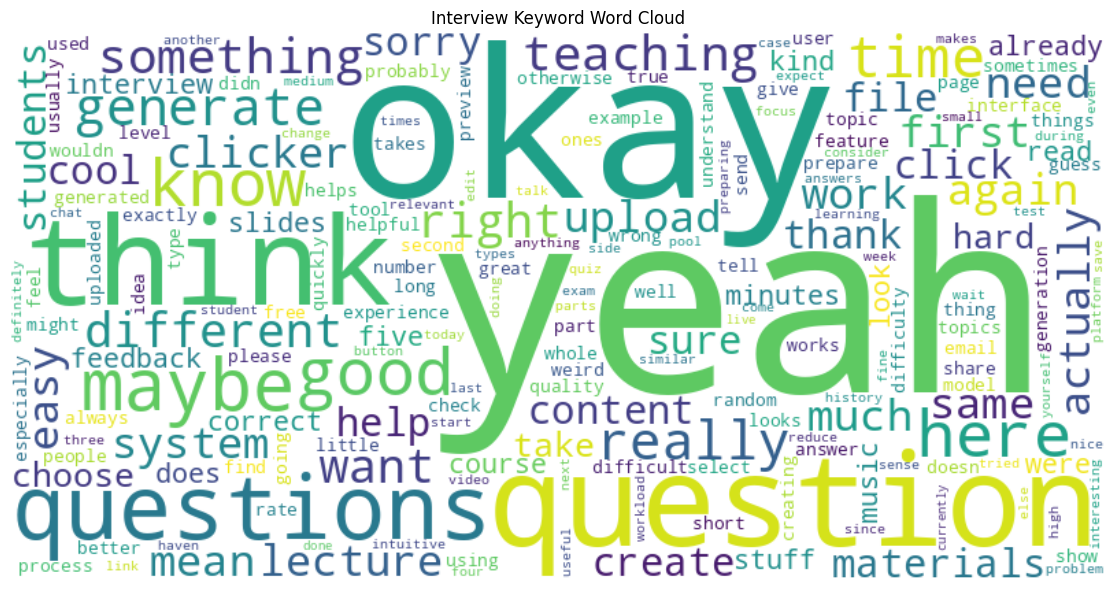

In [4]:
import os
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import re

# Load all the interview files
file_paths = [
    "/content/Benjamin-interview.txt",
    "/content/Interview-Roland.txt",
    "/content/Interview-Selina.txt",
    "/content/Roy-interview.txt",
    "/content/Thomas-interview.txt"
]

# Combine text from all files
all_text = ""
for path in file_paths:
    with open(path, 'r', encoding='utf-8') as f:
        all_text += f.read().lower() + "\n"

# Basic cleaning and tokenization
tokens = re.findall(r'\b[a-z]{4,}\b', all_text)  # words with at least 4 letters
stop_words = set([
    'that', 'this', 'with', 'from', 'have', 'would', 'what', 'which',
    'will', 'they', 'about', 'when', 'where', 'there', 'their', 'them',
    'just', 'also', 'because', 'some', 'very', 'like', 'then', 'been',
    'more', 'only', 'into', 'than', 'each', 'such', 'most', 'many',
    'your', 'could', 'those', 'every', 'should', 'being', 'other',
    'make', 'through', 'these', 'while', 'before', 'after', 'still'
])
filtered_tokens = [word for word in tokens if word not in stop_words]

# Count frequencies
word_counts = Counter(filtered_tokens)

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)


plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Interview Keyword Word Cloud')
plt.tight_layout()
plt.show()


# Topic distribution bar chart

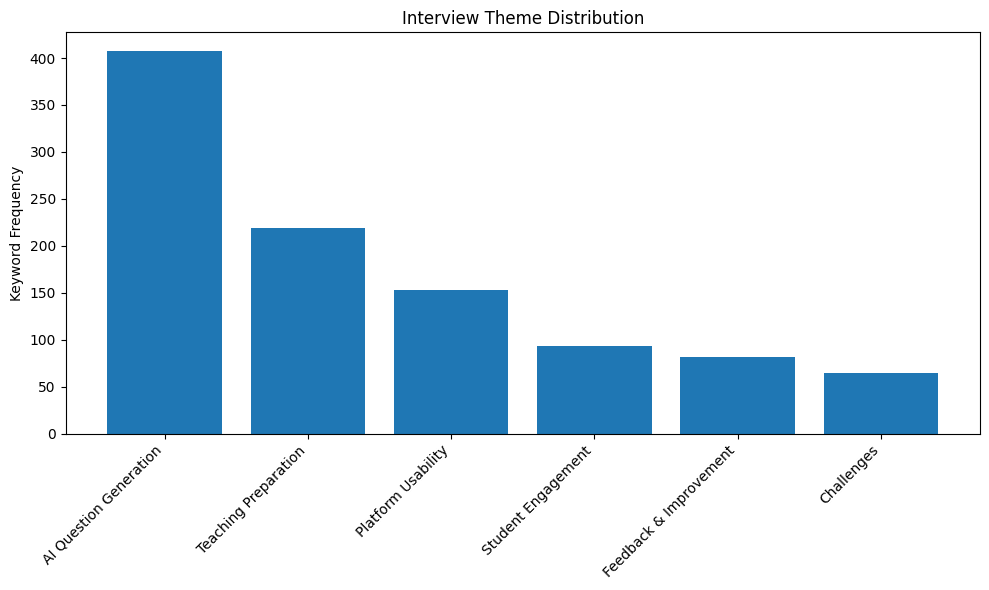

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define rough thematic categories and associated keywords
themes = {
    "AI Question Generation": ["ai", "generate", "question", "generation", "automatically", "system"],
    "Teaching Preparation": ["lecture", "slides", "material", "prepare", "time", "content"],
    "Platform Usability": ["interface", "easy", "click", "upload", "screen", "button"],
    "Feedback & Improvement": ["feedback", "rate", "edit", "correct", "improve"],
    "Student Engagement": ["students", "quiz", "practice", "classroom", "clicker"],
    "Challenges": ["challenge", "problem", "difficult", "hard", "issue"]
}

# Count theme-related keywords in the filtered tokens
theme_counts = {}
for theme, keywords in themes.items():
    theme_counts[theme] = sum(word_counts[k] for k in keywords if k in word_counts)

# Convert to DataFrame for plotting
theme_df = pd.DataFrame(list(theme_counts.items()), columns=["Theme", "Count"])
theme_df.sort_values(by="Count", ascending=False, inplace=True)

# Plot as a bar chart
plt.figure(figsize=(10, 6))
plt.bar(theme_df["Theme"], theme_df["Count"])
plt.title("Interview Theme Distribution")
plt.ylabel("Keyword Frequency")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Topic distribution bar chart, showing the frequency of different topics in the interview.
• AI Question Generation and Teaching Preparation were the topics that came up most frequently, indicating a strong interest in reducing the burden of lesson preparation through AI.
• Platform Usability and Student Engagement are also frequently mentioned.
• Challenges and Feedback & Improvement, although less frequent, are also areas that teachers care about very much.



# Sentiment Trend Chart

In [5]:
pip install matplotlib textblob seaborn


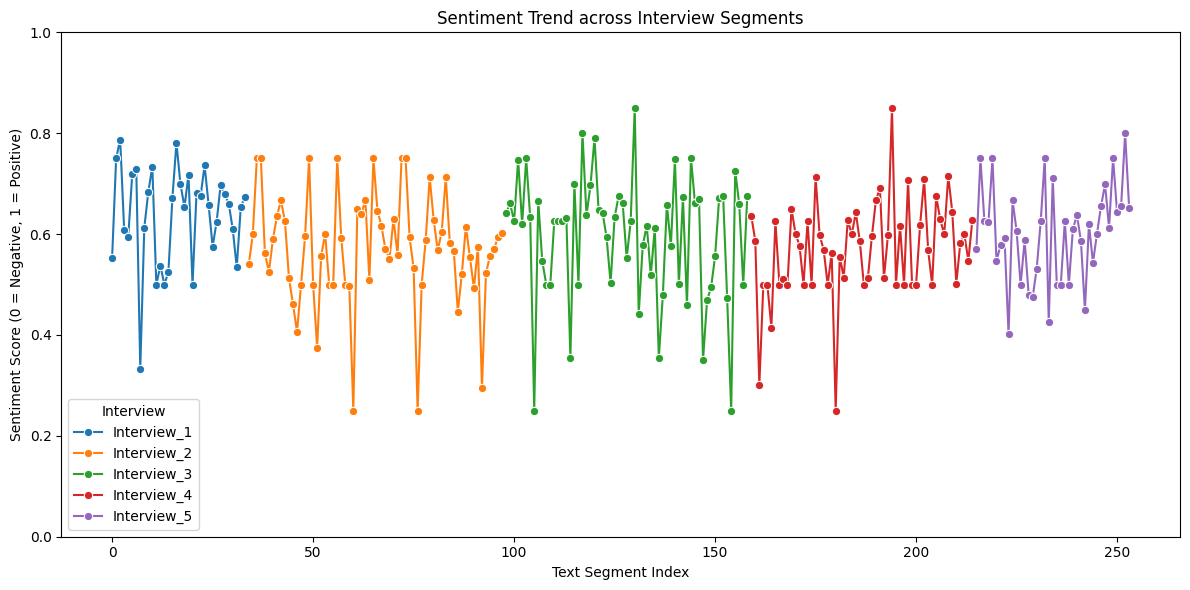

In [7]:
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from textblob import TextBlob

interview_blocks = []
for path in file_paths:
    with open(path, 'r', encoding='utf-8') as f:
        text = f.read()
        blocks = re.split(r'\n{2,}', text)  # 用空行分段
        interview_blocks.append(blocks)

# Sentiment analysis using TextBlob
sentiment_scores = []
interview_labels = []

for i, blocks in enumerate(interview_blocks):
    for block in blocks:
        block = block.strip()
        if len(block) > 30:
            blob = TextBlob(block)
            score = blob.sentiment.polarity
            normalized = (score + 1) / 2
            sentiment_scores.append(normalized)
            interview_labels.append(f"Interview_{i+1}")

# Generate a DataFrame for visualization
sentiment_df = pd.DataFrame({
    "Sentiment": sentiment_scores,
    "Interview": interview_labels
})


plt.figure(figsize=(12, 6))
sns.lineplot(data=sentiment_df, x=range(len(sentiment_df)), y="Sentiment", hue="Interview", marker='o')
plt.title("Sentiment Trend across Interview Segments")
plt.xlabel("Text Segment Index")
plt.ylabel("Sentiment Score (0 = Negative, 1 = Positive)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


* In Interview 3 (Selina) and Interview 4 (Roy), the overall emotional value is
high, indicating that they are more positive about AI-assisted systems.
* In Interview 5 (Thomas), the emotional value of some paragraphs fluctuates significantly, which may be the parts that encounter system errors or express critical suggestions.
* Interviews 1 and 2 (Benjamin and Roland) are emotionally stable, but have some neutral or slightly negative parts


